# Generativna umjetna inteligencija u sustavima obnovljivih izvora energije
## Praktični dio — priprema podataka, model i rezultati

Josip Ančić, završni rad, FOI 2026.

Podaci: OPSD *Household Data* (CoSSMic, Konstanz) — kućanstvo `residential4`.
Cijeli tijek prati CRISP-DM: priprema podataka → modeliranje (cVAE) → evaluacija.

## 1. Priprema podataka

Mjerenja su kumulativna stanja brojila (kWh koji samo raste), pa satnu energiju dobivamo `diff()`-om. Negativne razlike i nemogući skokovi (ispadi opreme) izbacuju se, a potrošnja se računa iz bilance: `pv + preuzeto − predano`. Zadržavamo samo dane s barem 22 sata valjanih mjerenja.

In [ ]:
import numpy as np
import pandas as pd

KUCANSTVO = "residential4"
POCETAK, KRAJ = "2015-10-11", "2018-02-03"
NAJMANJE_SATI = 22
FAKTOR_STRSILA = 3

sirovi = pd.read_csv("../household_data_60min_singleindex.csv",
                     parse_dates=["utc_timestamp"], index_col="utc_timestamp",
                     low_memory=False)

proizvodnja = sirovi[f"DE_KN_{KUCANSTVO}_pv"]
preuzeto = sirovi[f"DE_KN_{KUCANSTVO}_grid_import"]
predano = sirovi[f"DE_KN_{KUCANSTVO}_grid_export"]

satno = pd.DataFrame({"pv": proizvodnja.diff(),
                      "imp": preuzeto.diff(),
                      "exp": predano.diff()})
satno[satno < 0] = np.nan
for stupac in satno:
    granica = satno[stupac].quantile(0.9999) * FAKTOR_STRSILA
    satno.loc[satno[stupac] > granica, stupac] = np.nan

satno["cons"] = satno["pv"] + satno["imp"] - satno["exp"]
satno.loc[satno["cons"] < 0, "cons"] = np.nan
satno = satno.dropna(subset=["pv", "cons"])[POCETAK:KRAJ]

dnevno = satno.resample("D").agg({"pv": "sum", "cons": "sum",
                                  "imp": "sum", "exp": "sum"})
dnevno["izmjereno_sati"] = satno["pv"].resample("D").count()
dnevno = dnevno[dnevno["izmjereno_sati"] >= NAJMANJE_SATI].drop(columns="izmjereno_sati")

print(f"satnih zapisa: {len(satno)} | potpunih dana: {len(dnevno)}")
print(dnevno.describe().round(2).to_string())

satnih zapisa: 20264 | potpunih dana: 835
           pv    cons     imp     exp
count  835.00  835.00  835.00  835.00
mean    29.09   18.66   12.00   22.43
std     19.36   10.57    9.71   18.68
min      0.06    3.96    1.53    0.00
25%     13.39    9.23    3.36    5.34
50%     25.99   15.89    8.27   18.29
75%     45.80   26.48   20.63   38.38
max     68.07   55.06   43.48   63.89


## 2. Eksplorativna analiza

Dva ključna obrasca: **sezonalnost** (ljeti i do 5× veća proizvodnja, a potrošnja najveća zimi) i **oblik dana** (proizvodnja zvonolika s vrhom oko podneva; potrošnja s jutarnjim i večernjim vrhom). Udio samopotrošnje u razdoblju: **22,9 %**.

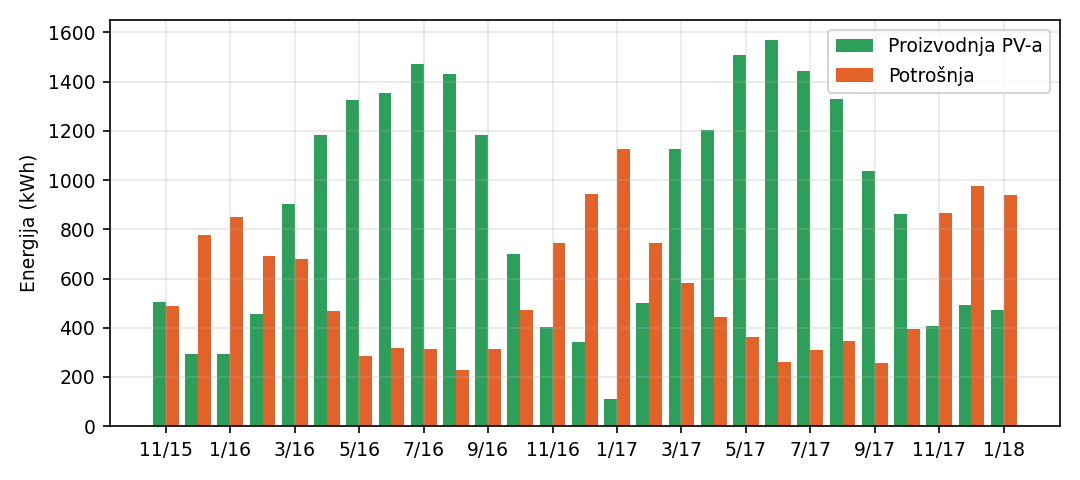

In [ ]:
# Slika 1: mjesečna proizvodnja i potrošnja (kod u eda_grafovi.py)
m = full.resample('MS').sum()['2015-11':'2018-01']
# ... crtanje ...

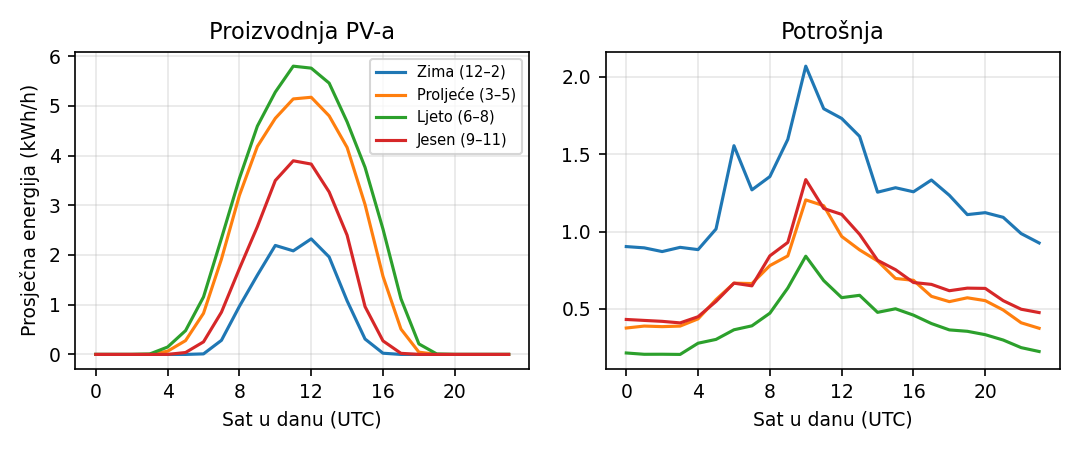

In [ ]:
# Slika 2: prosječni dnevni profili po sezonama

## 3. Model — uvjetni varijacijski autoenkoder (cVAE)

Ulaz je dnevni profil (24 satne vrijednosti), a uvjeti su **mjesec** (one-hot), **energija prethodnog dana** i **oznaka vikenda**. Enkoder: 38→64→(μ, log σ²) u 8 dimenzija; dekoder: 22→64→24. Funkcija gubitka: rekonstrukcija + **β·KL** (β = 0,1 — manja težina daje raznolikije scenarije, ista ideja kao alpha u Ridge regresiji). Sve implementirano od nule u NumPyju, uključujući backprop — puni kod u `cvae_model.py`.

**Podjela podataka:** po uzoru na Dumas i sur. (2022), dani se dijele nasumično, **stratificirano po mjesecima** (75 % / 25 %), pa su sve sezone u oba skupa.

In [ ]:
# treniranje oba modela (proizvodnja i potrošnja) — skripta: cvae_model.py
# ovdje prikazujemo ispis pokretanja:
%run cvae_model.py

== pv == train 615 / test 204
  cVAE           MAE=0.515 RMSE=1.021
  Klimatologija  MAE=0.542 RMSE=1.038
  Persistencija  MAE=0.560 RMSE=1.296
  sijecanj: scen mean=11.3 std=7.0 | stvarno mean=9.9 std=8.6
  lipanj: scen mean=48.2 std=11.3 | stvarno mean=48.6 std=13.7
== potrosnja == train 615 / test 204
  cVAE           MAE=0.347 RMSE=0.540
  Klimatologija  MAE=0.348 RMSE=0.544
  Persistencija  MAE=0.401 RMSE=0.699
GOTOVO


**Čitanje rezultata:** cVAE ima najmanju pogrešku po objema mjerama za obje serije. Persistencija najviše strada po RMSE-u (velike pogreške pri naglim promjenama vremena). Zimski scenariji dobro prate stvarne vrijednosti (std 7,0 prema stvarnih 8,6) — prije stratificirane podjele bili su izrazito podcijenjeni.

## 4. Rezultati — scenariji i prognoze

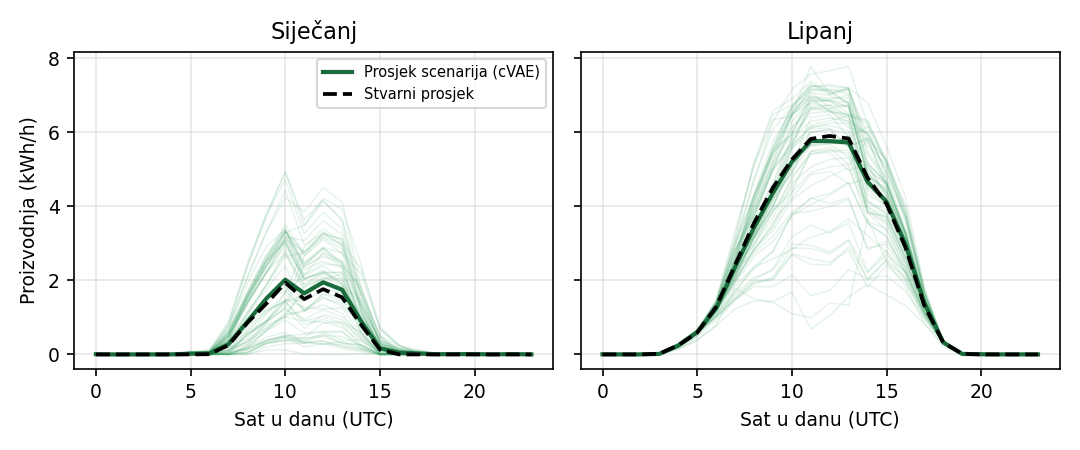

In [ ]:
# Slika 3: 60 generiranih scenarija + stvarni prosjek (siječanj / lipanj)

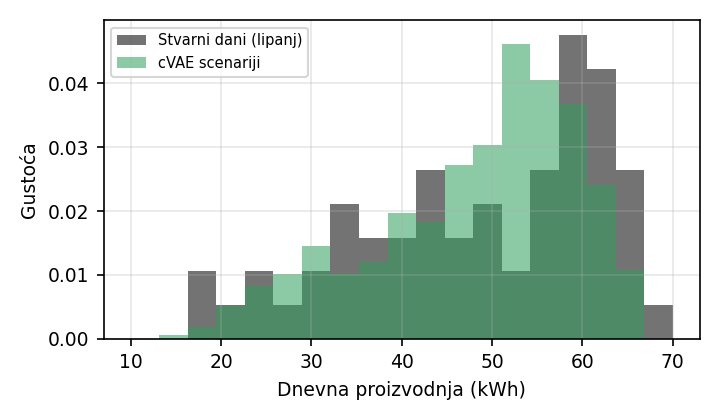

In [ ]:
# Slika 4: razdioba dnevne proizvodnje — stvarni lipanjski dani vs. scenariji

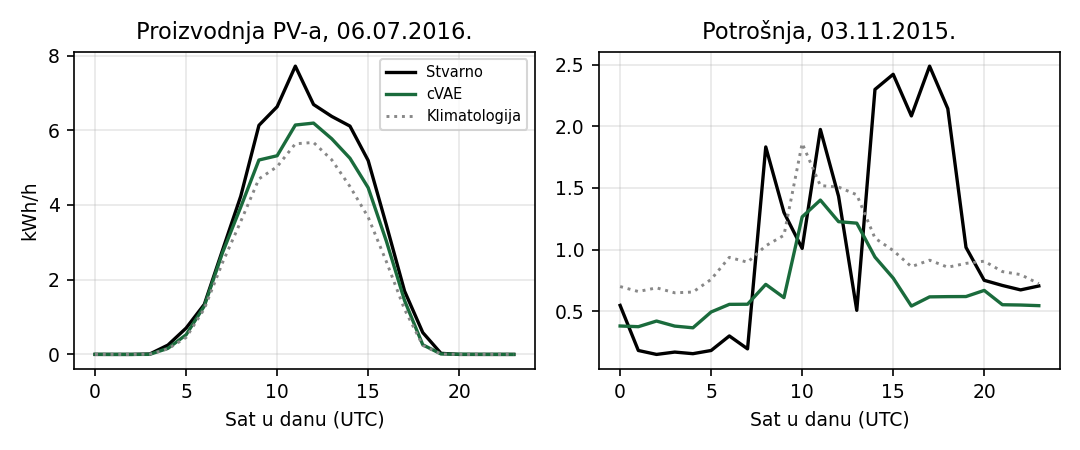

In [ ]:
# Slika 5: primjeri točkaste prognoze na testnim danima

## 5. Zaključak analize

- cVAE > klimatologija i persistencija po MAE i RMSE, za proizvodnju (1,021 kWh/h) i potrošnju (0,540 kWh/h)
- uz prognozu dobivamo i **scenarije s procjenom neizvjesnosti** — to referentni modeli nemaju
- lipanjska razdioba scenarija gotovo se poklapa sa stvarnom; blago zaglađivanje ostaje (poznato svojstvo VAE-a)
- način podjele podataka kod sezonskih serija bitno utječe na rezultat — stratificirana podjela po mjesecima

Detaljna interpretacija: poglavlja 7 i 8 završnog rada.